# Modern Portfolio Theory
Modern portfolio theory also popularly called Mean-Variance Portfolio Theory (MVP) is a major breakthrough in finance. It is based on the premise that returns are normally distributed and by looking at mean and variance, we can essentially describe the distribution of end-of-period wealth.

The basic idea of this theory is to achieve diversification by constructing a portfolio for a minimal portfolio risk or maximal portfolio returns. Accordingly, the **Efficient Frontier** is a set of optimal portfolios in the risk-return spectrum, and portfolios located under the Efficient Frontier curve are considered sub-optimal.

This means that the portfolios on the frontier offered

- `Highest expected return for a given level of risk`

- `Lowest level of risk for a given level of expected returns`

In essence, the investors' goal should be to select a level of risk that he/she is comfortable with and then find a portfolio that maximizes returns based on the selected risk level.

In [1]:
# Import pandas & yfinance
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

# Import numpy
import numpy as np
# from numpy import *
from numpy.linalg import multi_dot

# # Import cufflinks
# import cufflinks as cf
# cf.set_config_file(offline=True, dimensions=((1000,600))) # theme= 'henanigans'

# Import plotly express for EF plot
import plotly.express as px
# px.defaults.template = "plotly_dark"
px.defaults.width, px.defaults.height = 1000, 600

# # Machine info & package version
# from watermark import watermark
# %load_ext watermark
# %watermark -a "Kannan Singaravelu" -u -d -v -m -iv

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.precision', 4)

## Retrive Data

We will retrieve price data from our list of stocks as before to build our portfolio

In [2]:
# Specify assets / stocks
# international etf portfolio : 'SPY', 'GLD', 'IWM', 'VWO', 'BND']
# indian stocks : bank, consumer goods, diversified, it, consumer durables
assets = ['HDFCBANK', 'ITC', 'RELIANCE', 'TCS', 'ASIANPAINT']
assets.sort()

# Number of assets
numofasset = len(assets)

# Number of portfolio for optimization
numofportfolio = 5000

In [3]:
# Get yahoo tickers
yahooticker = [x+'.NS' for x in assets]
# Fetch / read data for multiple stocks at once
df = yf.download(yahooticker, start='2015-01-01', end='2022-12-31', progress=False)['Close']
df.columns = assets

# write data to file for future use
df.to_csv('stocks.csv')

# Read from file
df = pd.read_csv('stocks.csv', index_col=0, parse_dates=True)

# Display dataframe
df

YF.download() has changed argument auto_adjust default to True


,ASIANPAINT,HDFCBANK,ITC,RELIANCE,TCS
Date,,,,,
2015-01-01,695.7551,440.3434,178.3440,182.3744,1053.8416
2015-01-02,719.8092,446.4718,178.9026,181.8917,1067.8762
2015-01-05,719.7629,442.7022,179.6069,179.8994,1051.6475
2015-01-06,702.5814,435.8107,174.9923,171.7347,1012.8770
2015-01-07,716.6979,437.0827,171.7377,175.4730,1000.9126
...,...,...,...,...,...
2022-12-26,2996.3662,1589.2732,309.3030,1152.8959,3109.4946
2022-12-27,3051.8118,1590.8826,307.9626,1162.3281,3115.8037
2022-12-28,3062.6946,1589.6146,309.1181,1162.2140,3113.5095


## Visualize Time Series

<Axes: xlabel='Date'>

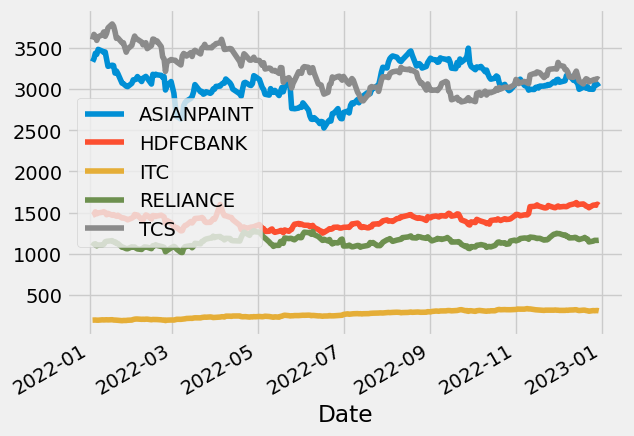

In [4]:
df['2022':].plot()

In [5]:
# Dataframe of returns and volatility
returns = df.pct_change().dropna()
df1 = pd.DataFrame({
    'Ann Ret': round(returns.mean()*252*100,2),  #252 days, *100 means % percerntage
    'Ann Vol': round(returns.std()*np.sqrt(252)*100,2) # for s.d. it should be squared root of 252 days
})
df1

,Ann Ret,Ann Vol
ASIANPAINT,22.27,26.46
HDFCBANK,19.10,23.38
ITC,10.47,26.59
RELIANCE,27.96,29.39
TCS,16.80,24.39


<Axes: title={'center': 'Annualized Return & Volatility (%)'}>

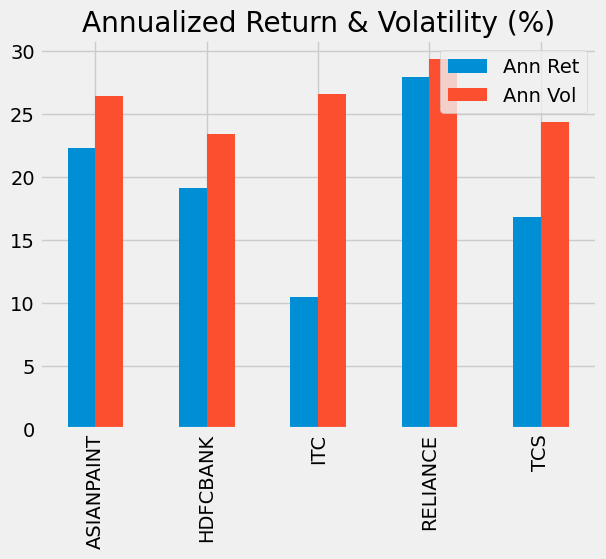

In [6]:
# Plot annualized return and volatility
df1.plot(
    kind='bar', 
    title='Annualized Return & Volatility (%)') #subplots=True

## Portfolio Composition

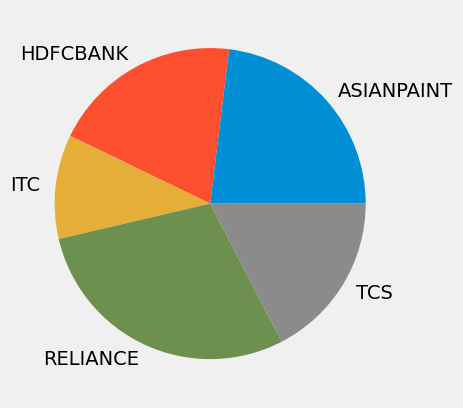

In [7]:
plt.pie(df1['Ann Ret'],
       labels=df1.index)
plt.show()

# Portfolio Statistics

## Notation
- $\vec{w}$, a vector of weights
- $\mu$, mean return of *n* assets

### Expected Portfolio Return
$$ \mu_{\pi} = w^T \mu $$
, which is equivalent to $\sum_{i=1}^n w_i \mu_i$.

### Expectd Portfolio Variance
$$ \sigma_{\pi}^2  = w^T \Sigma w$$
, where $\Sigma$ is the variance corvariance matrix.

## Portfolio Simulation

Now, we will implement a Monte Carlo simulation to generate random portfolio weights on a larger scale and calculate the expected portfolio return, variance and sharpe ratio for every simulated allocation. We will then identify the portfolio with a highest return for per unit of risk.

In [8]:
def portfolio_simulation(returns, numofportfolio = 5000):

    # Initialize the lists
    rets = []; vols = []; wts = []

    # Simulate 5,000 portfolios
    for i in range (numofportfolio):
        
        # Generate random weights
        weights = np.random.random(numofasset)[:, np.newaxis] # [:, np.newaxis] would make it a column vector
        
        # Set weights such that sum of weights equals 1
        weights /= sum(weights)
        
        # Portfolio statistics
        rets.append(weights.T @ np.array(returns.mean() * 252)[:, np.newaxis])        
        vols.append(np.sqrt(multi_dot([weights.T, returns.cov()*252, weights])))
        wts.append(weights.flatten())

    # Create a dataframe for analysis
    portdf = 100*pd.DataFrame({
        'port_rets': np.array(rets).flatten(),
        'port_vols': np.array(vols).flatten(),
        'weights': list(np.array(wts))
        })
    
    portdf['sharpe_ratio'] = portdf['port_rets'] / portdf['port_vols']

    return round(portdf,2)

## Maximum Sharpe Portfolio

In [9]:
# Create a dataframe for analysis
temp = portfolio_simulation(returns)
temp.head()

,port_rets,port_vols,weights,sharpe_ratio
0,20.82,18.85,"[1.82539683304422, 22.923912461441695, 0.68297...",1.10
1,19.11,17.93,"[26.58651714655625, 18.62390595997569, 30.2394...",1.07
2,20.75,18.51,"[1.7164700282389447, 28.632969140171138, 12.92...",1.12
3,20.98,19.02,"[6.541719070228455, 42.50091741216275, 12.7874...",1.10
4,21.26,18.73,"[8.048523493894741, 15.642890769323323, 1.6443...",1.13


In [10]:
# Get the max sharpe portfolio stats
# The One with Max Sharpe Ratio
temp.iloc[temp.sharpe_ratio.idxmax()]

port_rets                                                   21.65
port_vols                                                   17.96
weights         [25.86960282325415, 21.66794637935788, 1.48155...
sharpe_ratio                                                 1.21
Name: 3885, dtype: object

In [11]:
a = pd.Series(np.arange(10))
np.random.shuffle(a)
print(a[a])
print('-'*20)
print(".argmax() returns the max value's Order ")
print(a[a].argmax())
print('-'*20)
print(".idxmax() returns the max value's index # ")
print(a[a].idxmax())

9    3
4    6
1    4
2    1
6    0
5    5
0    9
7    7
8    8
3    2
dtype: int32
--------------------
.argmax() returns the max value's Order 
6
--------------------
.idxmax() returns the max value's index # 
0


In [12]:
# Verify the above result
temp.describe().T

,count,mean,std,min,25%,50%,75%,max
port_rets,5000.0,19.3124,1.6515,12.40,18.24,19.305,20.42,25.53
port_vols,5000.0,17.7889,0.8886,16.51,17.14,17.610,18.25,24.38
sharpe_ratio,5000.0,1.0859,0.0780,0.54,1.05,1.100,1.14,1.21


In [13]:
# Max sharpe ratio portfolio weights
msrpwts = temp['weights'][temp['sharpe_ratio'].idxmax()]

# Allocation to achieve max sharpe ratio portfolio
dict(zip(assets, np.around(msrpwts,2))) # np.around() means to round with 2 decimals

{'ASIANPAINT': 25.87,
 'HDFCBANK': 21.67,
 'ITC': 1.48,
 'RELIANCE': 27.14,
 'TCS': 23.84}

## Visulaize Simulated Portfolio

In [14]:
# Get the max sharpe portfolio stats
# The One with Max Sharpe Ratio
temp.iloc[temp.sharpe_ratio.idxmax()]

port_rets                                                   21.65
port_vols                                                   17.96
weights         [25.86960282325415, 21.66794637935788, 1.48155...
sharpe_ratio                                                 1.21
Name: 3885, dtype: object

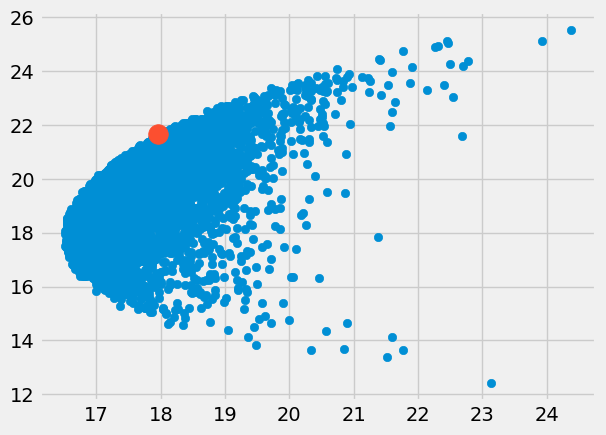

In [15]:
plt.scatter(x = temp.port_vols, y =temp.port_rets )
plt.scatter(x=temp.iloc[temp.sharpe_ratio.idxmax(),1] , y=temp.iloc[temp.sharpe_ratio.idxmax(),0], s=200)

# Efficient Frontier
The Efficient Frontier is formed by a set of portfolios offering the highest expected portfolio return for a certain volatility or offering the lowest volatility for a certain level of expected returns.

### Objective Function - Risks

$$ \min_w \sigma_p^2 $$
$$s.t. \quad \mathbb{E}(R_p) = m$$

### Objective Function - Returns

$$ \max_w \mathbb{E}(R_p) $$
$$s.t. \quad \sigma^2_p = v^2$$

, where $\sum_{i=1}^n w_i = 1$ for those two objective functions.

We can use numerical optimization to achieve this objective. The goal of optimization is to find the optimal value of the objective function by adjusting the target variables operating withing some boundary conditions and constraints.

## Constrained Optimization
Construction of optimal portfolios is a constrained optimization problem where we specify some boundary conditions and constraints. The objective function here is a function returning maximum sharpe ratio, minimum variance (volatility) and the target variables are portfolio weights. We will use the `minimize` function from `scipy` optimization module to achieve our objective.

https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html

In [16]:
# Import optimization module from scipy
import scipy.optimize as sco

## Portfolio Statistics
Let's subsume key statistics into a function which can be used for optimization exercise.

In [17]:
def portfolio_stats(weights):
    
    port_rets = weights.T @ np.array(returns.mean() * 252)[:,np.newaxis]    
    port_vols = np.sqrt(weights.T @ (returns.cov()*252) @ weights)
    
    return np.array([port_rets, port_vols, port_rets/port_vols]).flatten()


# Minimize the volatility
def min_volatility(weights):
    return portfolio_stats(weights)[1]

# Minimize the variance
def min_variance(weights):
    return portfolio_stats(weights)[1]**2

# Maximizing sharpe ratio
def max_sharpe_ratio(weights):
    return -portfolio_stats(weights)[2] # mini minus func <=> max func

## Efficient Frontier Portfolio - Build the Optimiser
For efficient frontier portfolios, we fix a target return and derive for objective function.

In [18]:
max_sharpe_ratio

<function __main__.max_sharpe_ratio(weights)>

In [19]:
# Specify constraints, bounds and initial weights
cons = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bnds = tuple((0, 1) for x in range(numofasset))
initial_wts = numofasset*[1./numofasset]

In [20]:
# Optimizing for maximum sharpe ratio  <-- Optimal Shape
opt_sharpe = sco.minimize(max_sharpe_ratio, initial_wts, method='SLSQP', bounds=bnds, constraints=cons)

# Optimizing for minimum variance <-- Global Mini Var
opt_var = sco.minimize(min_variance, initial_wts, method='SLSQP', bounds=bnds, constraints=cons)

In [21]:
# Efficient Frontier
# targetrets = linspace(0.01,0.11,100)
targetrets = np.linspace(0.155,0.24,100)
tvols = []

for tr in targetrets:
    
    ef_cons = ({'type': 'eq', 'fun': lambda x: portfolio_stats(x)[0] - tr},
               {'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    
    opt_ef = sco.minimize(min_volatility, initial_wts, method='SLSQP', bounds=bnds, constraints=ef_cons)
    
    tvols.append(opt_ef['fun'])

targetvols = np.array(tvols)

In [22]:
# Create EF Dataframe for plotting
efport = pd.DataFrame({
    'targetrets' : np.around(100*targetrets,2),
    'targetvols': np.around(100*targetvols,2),
    'targetsharpe': np.around(targetrets/targetvols,2)
})

efport.head()

,targetrets,targetvols,targetsharpe
0,15.50,17.18,0.90
1,15.59,17.12,0.91
2,15.67,17.07,0.92
3,15.76,17.02,0.93
4,15.84,16.97,0.93


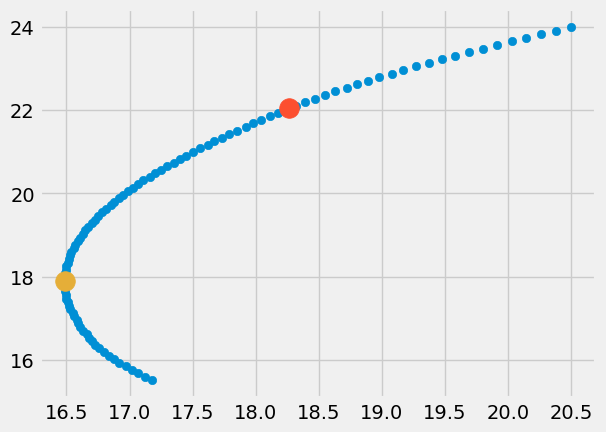

In [23]:
plt.scatter(x= efport.targetvols, y = efport.targetrets)
plt.scatter(x=  [100*portfolio_stats(opt_sharpe['x'])[1]], y = [100*portfolio_stats(opt_sharpe['x'])[0]], s=200)
plt.scatter(x=  [100*portfolio_stats(opt_var['x'])[1]], y = [100*portfolio_stats(opt_var['x'])[0]], s=200)
plt.show()